In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df=pd.read_csv('/content/part_5_customer_ltv_prediction.csv')
df.head()

,CustomerID,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,LoyaltyTier,DiscountUsedLastCampaign,Year1Spending,FutureSpending
0,LTV00001,33,64196.02,145,61,19,1403.79,242,0.136,0.028,Gold,No,25356.80,12438.46
1,LTV00002,46,69889.53,153,111,2,988.47,223,0.126,0.067,Silver,Yes,2768.68,5860.22
2,LTV00003,20,83269.51,175,112,34,2386.24,101,0.026,0.087,Silver,No,80895.63,39203.34
3,LTV00004,44,79914.63,22,80,0,1121.87,98,0.037,0.004,Gold,Yes,874.95,3157.73
4,LTV00005,26,84091.39,24,166,12,1942.48,256,0.052,0.004,Gold,No,22962.40,11423.53


# Business Problem Understanding

The company wants to increase revenue from existing customers rather than spending heavily on acquiring new customers.

The objective of this project is to:
- Understand customer behavior
- Estimate customer lifetime value
- Segment customers based on value
- Predict future customer spending
- Improve retention and marketing strategies

Customer Lifetime Value (CLV) represents the total value a customer brings to the business over time.

Predicting future spending helps the company:
- Focus on high-value customers
- Reduce customer churn
- Improve marketing efficiency
- Increase long-term profitability

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                1400 non-null   object 
 1   Age                       1400 non-null   int64  
 2   AnnualIncome              1391 non-null   float64
 3   WebsiteVisits             1400 non-null   int64  
 4   AppSessions               1400 non-null   int64  
 5   PreviousOrders            1400 non-null   int64  
 6   AverageOrderValue         1390 non-null   float64
 7   DaysSinceLastPurchase     1400 non-null   int64  
 8   ReturnRate                1400 non-null   float64
 9   CancellationRate          1400 non-null   float64
 10  LoyaltyTier               1400 non-null   object 
 11  DiscountUsedLastCampaign  1400 non-null   object 
 12  Year1Spending             1400 non-null   float64
 13  FutureSpending            1400 non-null   float64
dtypes: float

In [6]:
df.describe()

,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,Year1Spending,FutureSpending
count,1400.000000,1391.000000,1400.000000,1400.000000,1400.000000,1390.000000,1400.000000,1400.00000,1400.000000,1400.000000,1400.00000
mean,41.605714,71444.250453,90.737143,132.418571,6.565714,1415.577691,183.185000,0.15199,0.108642,9134.559429,6313.12205
std,13.805044,24377.868323,52.795743,74.377160,7.040268,560.500299,104.939899,0.11240,0.090918,10302.771512,4753.00922
min,18.000000,18000.000000,0.000000,0.000000,0.000000,120.000000,0.000000,0.00000,0.000000,2.720000,0.00000
25%,30.000000,53835.975000,44.000000,69.000000,2.000000,1047.412500,90.000000,0.06800,0.041000,2141.730000,3268.38000
50%,41.000000,71166.060000,91.000000,135.000000,4.000000,1405.770000,182.000000,0.12600,0.085000,5961.810000,5169.58500
75%,54.000000,87956.155000,138.000000,195.000000,9.000000,1787.925000,272.000000,0.21400,0.150250,12564.177500,8096.47750
max,65.000000,151693.240000,180.000000,260.000000,65.000000,3206.800000,365.000000,0.73500,0.605000,118597.670000,54797.19000


In [7]:
print(df.columns)

Index(['CustomerID', 'Age', 'AnnualIncome', 'WebsiteVisits', 'AppSessions',
       'PreviousOrders', 'AverageOrderValue', 'DaysSinceLastPurchase',
       'ReturnRate', 'CancellationRate', 'LoyaltyTier',
       'DiscountUsedLastCampaign', 'Year1Spending', 'FutureSpending'],
      dtype='object')


# Data Understanding

Important Columns:
- Customer_ID → Unique customer identifier
- Age → Customer age
- Income → Customer income
- Website_Visits → Number of website visits
- Previous_Spending → Past customer spending
- Number_of_Orders → Total orders placed
- Average_Order_Value → Average order amount
- Active_Days → Customer engagement days
- Return_Rate → Product return percentage
- Cancellation_Rate → Order cancellation percentage
- Future_Spending → Target variable
- Customer_Value_Score → Customer value indicator

Future_Spending is the target variable.

This is a regression problem because the target variable is continuous numerical data.

In [8]:
df.isnull().sum()

,0
CustomerID,0
Age,0
AnnualIncome,9
WebsiteVisits,0
AppSessions,0
PreviousOrders,0
AverageOrderValue,10
DaysSinceLastPurchase,0
ReturnRate,0
CancellationRate,0


In [9]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.dtypes

,0
CustomerID,object
Age,int64
AnnualIncome,float64
WebsiteVisits,int64
AppSessions,int64
PreviousOrders,int64
AverageOrderValue,float64
DaysSinceLastPurchase,int64
ReturnRate,float64
CancellationRate,float64


In [13]:
df['Engagement_Score'] = (
    df['WebsiteVisits'] +
    df['AppSessions']
)

In [14]:
df['Spending_Growth'] = (
    df['Year1Spending'] /
    (df['PreviousOrders'] + 1)
)

# Feature Engineering

Created Features:
- Engagement_Score → Measures customer activity
- Spending_Growth → Measures spending behavior

These features help improve prediction accuracy.

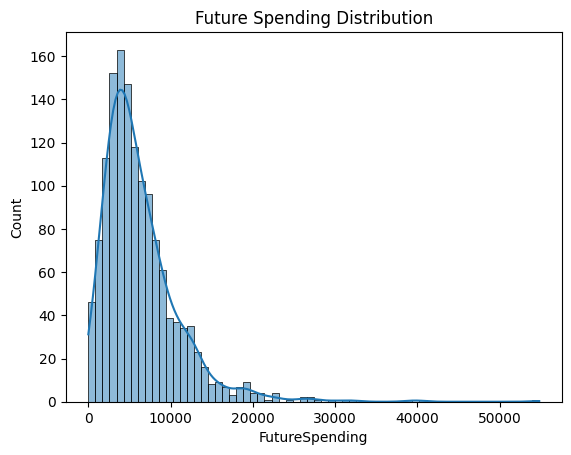

In [15]:
sns.histplot(df['FutureSpending'], kde=True)

plt.title('Future Spending Distribution')

plt.show()

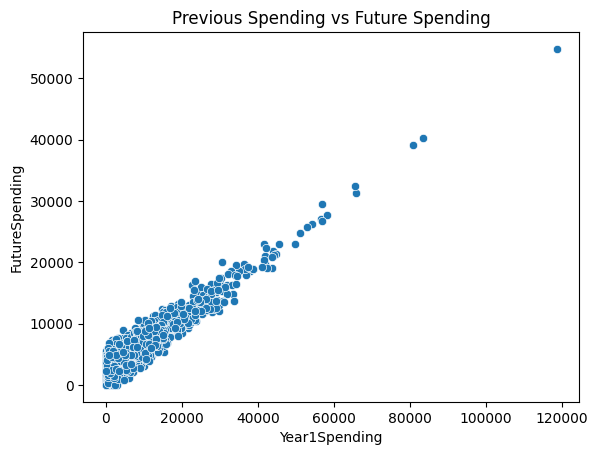

In [16]:
sns.scatterplot(
    x=df['Year1Spending'],
    y=df['FutureSpending']
)

plt.title('Previous Spending vs Future Spending')

plt.show()

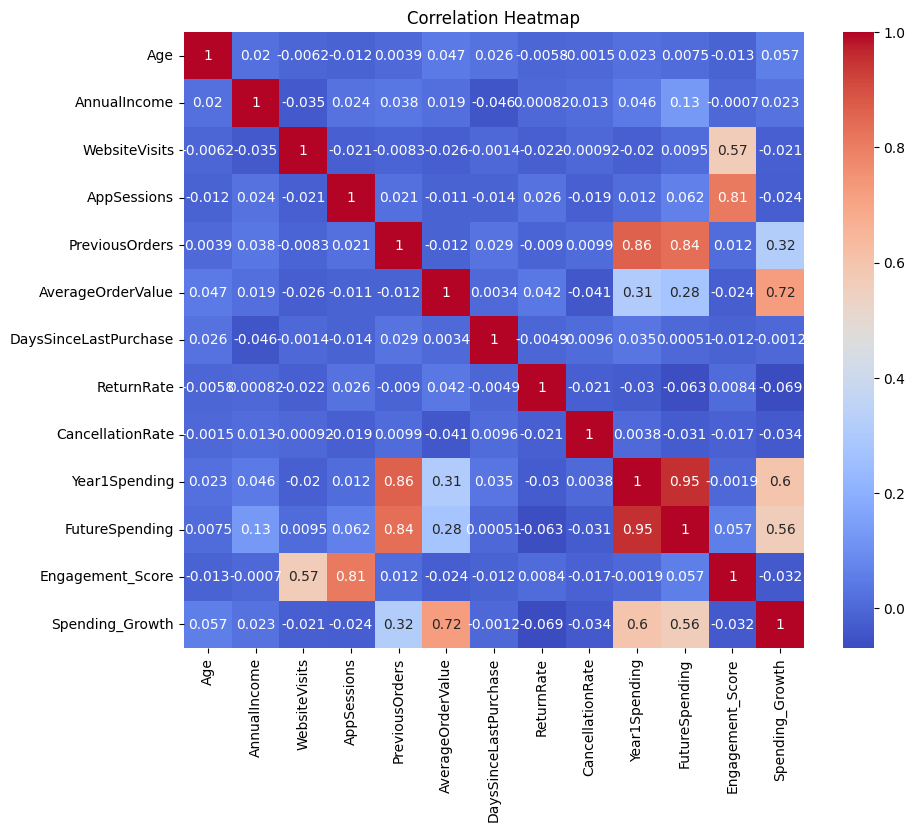

In [17]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# EDA Insights

Key Observations:
- Previous spending strongly affects future spending
- Customers with higher income tend to spend more
- High cancellation rates reduce future spending
- Active customers show better engagement and spending patterns

In [20]:
segmentation_data = df[[
    'AnnualIncome',
    'Year1Spending',
    'LoyaltyTier'
]]

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['LoyaltyTier'] = le.fit_transform(df['LoyaltyTier'])

In [30]:
segmentation_data = df[[
    'AnnualIncome',
    'Year1Spending',
    'Age',
    'LoyaltyTier'
]]

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Customer_Segment'] = kmeans.fit_predict(segmentation_data)

In [32]:
print(df[['Customer_Segment']].head())

   Customer_Segment
0                 0
1                 0
2                 0
3                 0
4                 0


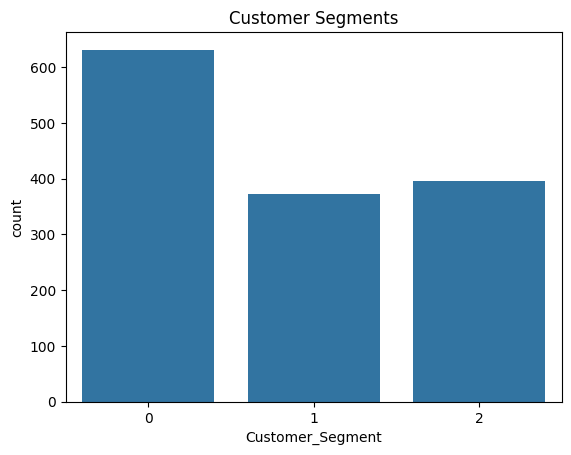

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Customer_Segment'])
plt.title("Customer Segments")
plt.show()

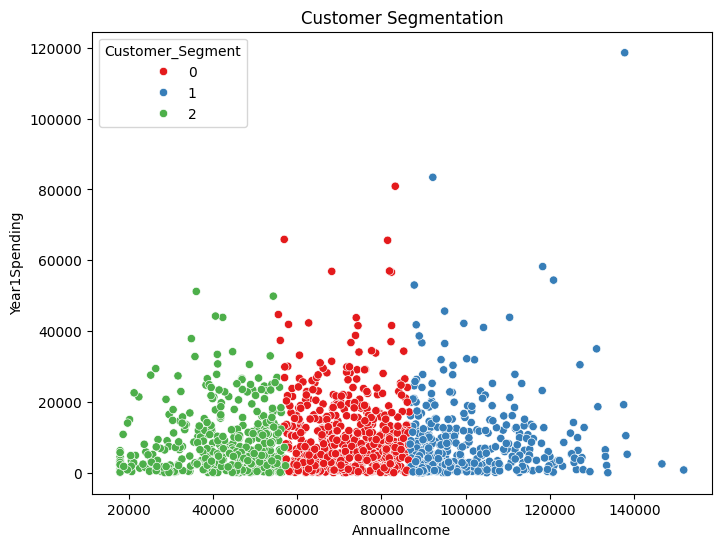

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['AnnualIncome'],
    y=df['Year1Spending'],
    hue=df['Customer_Segment'],
    palette='Set1'
)

plt.title('Customer Segmentation')

plt.show()

# Customer Segmentation Insights

Customers were grouped into:
1. High-value customers
2. Medium-value customers
3. Low-value customers

This segmentation helps businesses target customers more effectively.

In [38]:
X = df[[
    'AnnualIncome',
    'WebsiteVisits',
    'Year1Spending',
    'PreviousOrders',
    'AverageOrderValue',
    'DaysSinceLastPurchase',
    'ReturnRate',
    'DiscountUsedLastCampaign',
    'LoyaltyTier'
]]

y = df['FutureSpending']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['DiscountUsedLastCampaign'] = le.fit_transform(
    df['DiscountUsedLastCampaign']
)

In [42]:
df['LoyaltyTier'] = le.fit_transform(df['LoyaltyTier'])

In [43]:
X = df[[
    'AnnualIncome',
    'WebsiteVisits',
    'Year1Spending',
    'PreviousOrders',
    'AverageOrderValue',
    'DaysSinceLastPurchase',
    'ReturnRate',
    'DiscountUsedLastCampaign',
    'LoyaltyTier'
]]

y = df['FutureSpending']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

In [46]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [47]:
y_pred = model.predict(X_test)

In [48]:
print("R2 Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9098719182485974
MAE: 1083.6564981427325
RMSE: 1374.2492716626866


In [49]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,AnnualIncome,0.017160
1,WebsiteVisits,2.555464
2,Year1Spending,0.424216
3,PreviousOrders,25.349611
4,AverageOrderValue,-0.020717
5,DaysSinceLastPurchase,-1.048215
6,ReturnRate,-1702.434372
7,DiscountUsedLastCampaign,393.360855
8,LoyaltyTier,162.556380


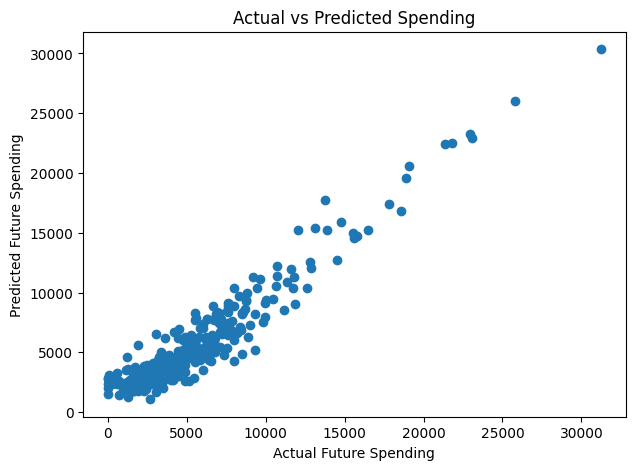

In [50]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Future Spending")

plt.ylabel("Predicted Future Spending")

plt.title("Actual vs Predicted Spending")

plt.show()

# Regression Model Summary

Linear Regression was used to predict future customer spending.

Model evaluation was performed using:
- R² Score
- MAE
- RMSE

The model helps estimate future customer value and supports business decision-making.

# Business Recommendations

1. Focus on high-value customers.
2. Improve customer retention strategies.
3. Reduce return and cancellation rates.
4. Increase customer engagement through loyalty programs.
5. Personalize offers based on spending behavior.
6. Encourage repeat purchases.
7. Use predictive analytics for targeted marketing campaigns.